#  Limpieza de Datos - PetFinder.my Adoption Prediction

Este notebook limpia el dataset y genera `train_clean.csv`, que es el archivo que usará el modelo.

**Problemas detectados:**
- Valores nulos en `Name` (1265) y `Description` (13)
- Outliers en `Age` (valores 0 y >100 meses)
- Outliers en `Fee` (valores >500)
- Outliers en `Quantity` (valores >10)
- `Breed2`, `Color2`, `Color3` con valor 0 (sin segunda raza/color)

## 1. Importaciones y carga

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)

df = pd.read_csv('../data/train.csv')
print(f'Shape original: {df.shape}')
df.head(3)

Shape original: (14993, 24)


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,...,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,...,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,...,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3


## 2. Estado inicial del dataset

In [8]:
print('=== NULOS ===')
nulos = df.isnull().sum()
print(nulos[nulos > 0])

print(f'\n=== DUPLICADOS ===')
print(f'Filas duplicadas: {df.duplicated().sum()}')

print('\n=== RESUMEN NUMÉRICO ===')
df.describe().round(2)

=== NULOS ===
Name           1265
Description      13
dtype: int64

=== DUPLICADOS ===
Filas duplicadas: 0

=== RESUMEN NUMÉRICO ===


,Type,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,VideoAmt,PhotoAmt,AdoptionSpeed
count,14993.00,14993.00,14993.00,14993.00,14993.00,14993.00,14993.00,14993.00,14993.00,14993.00,14993.00,14993.00,14993.00,14993.00,14993.00,14993.00,14993.00,14993.00,14993.00,14993.00
mean,1.46,10.45,265.27,74.01,1.78,2.23,3.22,1.88,1.86,1.47,1.73,1.56,1.91,1.04,1.58,21.26,41346.03,0.06,3.89,2.52
std,0.50,18.16,60.06,123.01,0.68,1.75,2.74,2.98,0.55,0.60,0.67,0.70,0.57,0.20,1.47,78.41,32.44,0.35,3.49,1.18
min,1.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,41324.00,0.00,0.00,0.00
25%,1.00,2.00,265.00,0.00,1.00,1.00,0.00,0.00,2.00,1.00,1.00,1.00,2.00,1.00,1.00,0.00,41326.00,0.00,2.00,2.00
50%,1.00,3.00,266.00,0.00,2.00,2.00,2.00,0.00,2.00,1.00,2.00,1.00,2.00,1.00,1.00,0.00,41326.00,0.00,3.00,2.00
75%,2.00,12.00,307.00,179.00,2.00,3.00,6.00,5.00,2.00,2.00,2.00,2.00,2.00,1.00,1.00,0.00,41401.00,0.00,5.00,4.00
max,2.00,255.00,307.00,307.00,3.00,7.00,7.00,7.00,4.00,3.00,3.00,3.00,3.00,3.00,20.00,3000.00,41415.00,8.00,30.00,4.00


## 3.  Tratamiento de valores nulos

In [9]:
df_clean = df.copy()

# ── Name: nulo = sin nombre ──────────────────────────────────────────────────
# No rellenamos el nombre porque no se usa directamente como feature.
# El train.py ya crea has_name=0/1 a partir de si Name es nulo.
# Solo lo documentamos aquí.
print(f'Mascotas sin nombre: {df_clean["Name"].isna().sum()} '
      f'({df_clean["Name"].isna().mean()*100:.1f}%)')
print('→ Se conserva el nulo. El modelo usará has_name = 0/1')

# ── Description: 13 nulos → rellenar con cadena vacía ────────────────────────
before = df_clean['Description'].isna().sum()
df_clean['Description'] = df_clean['Description'].fillna('')
after  = df_clean['Description'].isna().sum()
print(f'\nDescription: {before} nulos → {after} nulos (rellenado con cadena vacía)')

# ── PhotoAmt: algún nulo (float) → 0 ─────────────────────────────────────────
df_clean['PhotoAmt'] = df_clean['PhotoAmt'].fillna(0)
print(f'PhotoAmt nulos restantes: {df_clean["PhotoAmt"].isna().sum()}')

Mascotas sin nombre: 1265 (8.4%)
→ Se conserva el nulo. El modelo usará has_name = 0/1

Description: 13 nulos → 0 nulos (rellenado con cadena vacía)
PhotoAmt nulos restantes: 0


## 4.  Outliers en Age

=== AGE - Casos problemáticos ===
Age = 0 meses:    179 registros
Age > 100 meses:  84 registros
Age > 150 meses:  10 registros

Valores extremos:
[255 255 238 212 212 212 180 180 168 156]


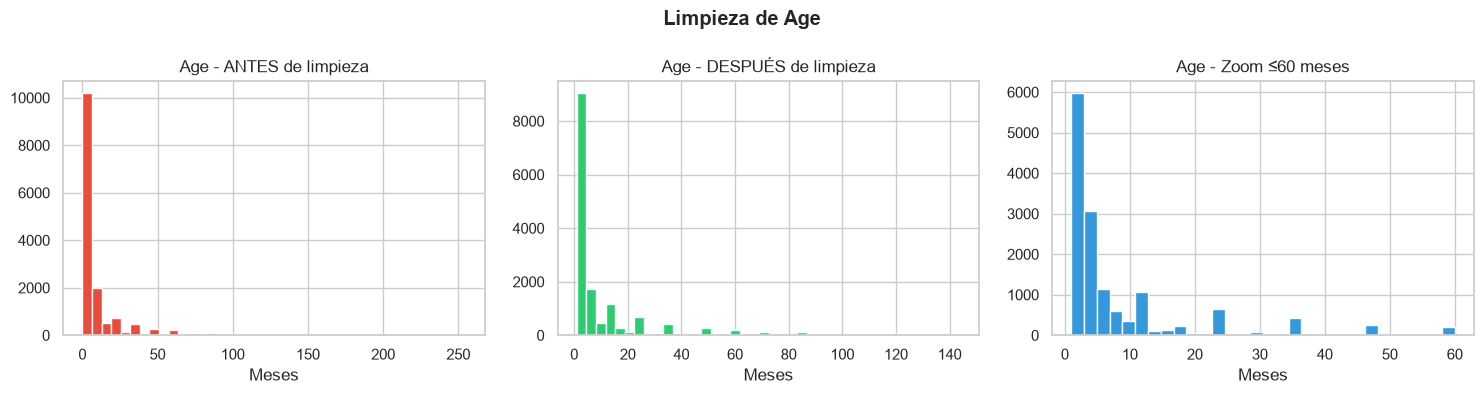


Age tras limpieza → min: 1, max: 144, mediana: 3.0


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Antes
axes[0].hist(df_clean['Age'], bins=40, color='#e74c3c', edgecolor='white')
axes[0].set_title('Age - ANTES de limpieza')
axes[0].set_xlabel('Meses')

print('=== AGE - Casos problemáticos ===')
print(f'Age = 0 meses:    {(df_clean["Age"] == 0).sum()} registros')
print(f'Age > 100 meses:  {(df_clean["Age"] > 100).sum()} registros')
print(f'Age > 150 meses:  {(df_clean["Age"] > 150).sum()} registros')
print(f'\nValores extremos:')
print(df_clean['Age'].nlargest(10).values)

# Decisión: Age=0 → 1 mes (recién nacido registrado como 0)
# Age > 144 meses (12 años) → cap a 144 (animales de refugio raramente tienen más)
df_clean['Age'] = df_clean['Age'].replace(0, 1)
df_clean['Age'] = df_clean['Age'].clip(upper=144)

# Después (filtrado)
axes[1].hist(df_clean['Age'], bins=40, color='#2ecc71', edgecolor='white')
axes[1].set_title('Age - DESPUÉS de limpieza')
axes[1].set_xlabel('Meses')

# Zoom en 0-60 meses
axes[2].hist(df_clean[df_clean['Age'] <= 60]['Age'], bins=30, color='#3498db', edgecolor='white')
axes[2].set_title('Age - Zoom ≤60 meses')
axes[2].set_xlabel('Meses')

plt.suptitle('Limpieza de Age', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nAge tras limpieza → min: {df_clean["Age"].min()}, max: {df_clean["Age"].max()}, mediana: {df_clean["Age"].median()}')

## 5.  Outliers en Fee

=== FEE - Casos problemáticos ===
Fee = 0 (gratis):   12663 (84.5%)
Fee > 500:          44 registros

Valores extremos:
[3000 2000 1000 1000 1000 1000  800  800  750  750]


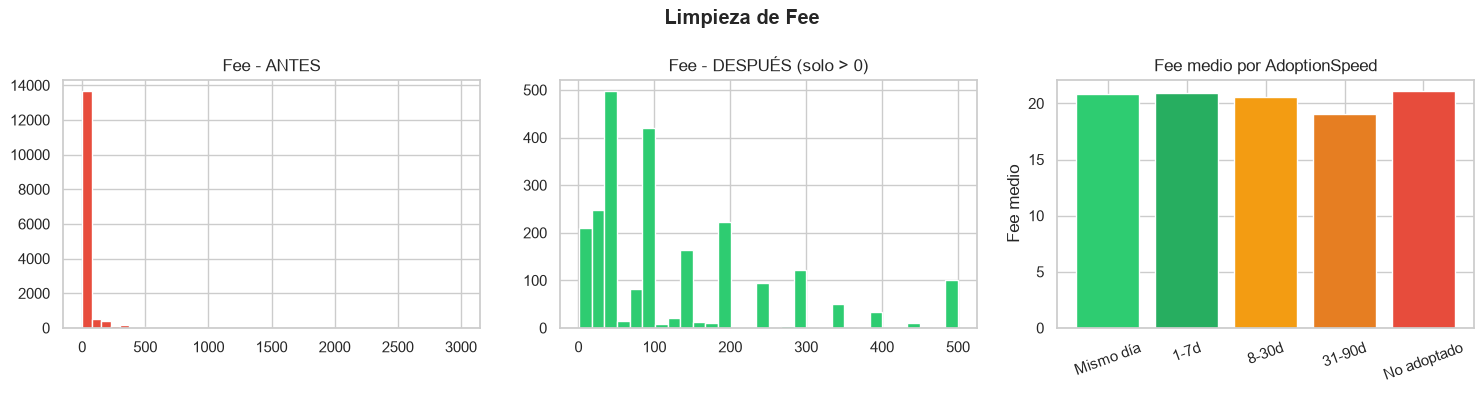

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_clean['Fee'], bins=40, color='#e74c3c', edgecolor='white')
axes[0].set_title('Fee - ANTES')

print('=== FEE - Casos problemáticos ===')
print(f'Fee = 0 (gratis):   {(df_clean["Fee"] == 0).sum()} ({(df_clean["Fee"] == 0).mean()*100:.1f}%)')
print(f'Fee > 500:          {(df_clean["Fee"] > 500).sum()} registros')
print(f'\nValores extremos:')
print(df_clean['Fee'].nlargest(10).values)

# Cap a 500 (outliers extremos probablemente errores de entrada)
df_clean['Fee'] = df_clean['Fee'].clip(upper=500)

axes[1].hist(df_clean[df_clean['Fee'] > 0]['Fee'], bins=30, color='#2ecc71', edgecolor='white')
axes[1].set_title('Fee - DESPUÉS (solo > 0)')

# Distribución por AdoptionSpeed
fee_means = df_clean.groupby('AdoptionSpeed')['Fee'].mean()
speed_labels = {0:'Mismo día',1:'1-7d',2:'8-30d',3:'31-90d',4:'No adoptado'}
axes[2].bar([speed_labels[i] for i in fee_means.index], fee_means.values,
            color=['#2ecc71','#27ae60','#f39c12','#e67e22','#e74c3c'], edgecolor='white')
axes[2].set_title('Fee medio por AdoptionSpeed')
axes[2].set_ylabel('Fee medio')
axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('Limpieza de Fee', fontweight='bold')
plt.tight_layout()
plt.show()

## 6.  Outliers en Quantity

In [12]:
print('=== QUANTITY ===')
print(df_clean['Quantity'].value_counts().sort_index().head(15))
print(f'\nQuantity > 10: {(df_clean["Quantity"] > 10).sum()} registros')

# Cap a 10 (anuncios con más de 10 son casos muy extremos/erróneos)
df_clean['Quantity'] = df_clean['Quantity'].clip(upper=10)
print(f'Tras cap: max = {df_clean["Quantity"].max()}')

=== QUANTITY ===
Quantity
1     11565
2      1422
3       726
4       531
5       333
6       185
7        84
8        52
9        33
10       19
11       10
12        6
13        2
14        2
15        4
Name: count, dtype: int64

Quantity > 10: 43 registros
Tras cap: max = 10


## 7.  Consistencia en Breed y Color (valor 0 = sin dato)

In [13]:
# En PetFinder, 0 en Breed2/Color2/Color3 significa "no aplica" (no es un error)
# Lo documentamos y creamos features binarias para indicar si hay segunda raza/color

df_clean['has_breed2']  = (df_clean['Breed2']  != 0).astype(int)
df_clean['has_color2']  = (df_clean['Color2']  != 0).astype(int)
df_clean['has_color3']  = (df_clean['Color3']  != 0).astype(int)

print('=== Features de presencia creadas ===')
print(f'has_breed2  (mestizo con 2ª raza): {df_clean["has_breed2"].sum()} mascotas ({df_clean["has_breed2"].mean()*100:.1f}%)')
print(f'has_color2  (tiene 2º color):      {df_clean["has_color2"].sum()} mascotas ({df_clean["has_color2"].mean()*100:.1f}%)')
print(f'has_color3  (tiene 3er color):     {df_clean["has_color3"].sum()} mascotas ({df_clean["has_color3"].mean()*100:.1f}%)')

=== Features de presencia creadas ===
has_breed2  (mestizo con 2ª raza): 4231 mascotas (28.2%)
has_color2  (tiene 2º color):      10522 mascotas (70.2%)
has_color3  (tiene 3er color):     4389 mascotas (29.3%)


## 8.  PhotoAmt — verificación final

In [14]:
print('=== PHOTOAMT ===')
print(df_clean['PhotoAmt'].describe())
print(f'\nSin fotos: {(df_clean["PhotoAmt"] == 0).sum()} mascotas')

# Cap a 20 fotos (hay algunos outliers con 30)
df_clean['PhotoAmt'] = df_clean['PhotoAmt'].clip(upper=20)
print(f'Tras cap: max = {df_clean["PhotoAmt"].max()}')

=== PHOTOAMT ===
count    14993.000000
mean         3.889215
std          3.487810
min          0.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         30.000000
Name: PhotoAmt, dtype: float64

Sin fotos: 341 mascotas
Tras cap: max = 20.0


## 9.  Verificación final y guardado

In [15]:
print('=== COMPARACIÓN ANTES vs DESPUÉS ===')
comparison = pd.DataFrame({
    'Antes': [
        df.shape[0],
        df.duplicated().sum(),
        df.isnull().sum().sum(),
        int(df['Age'].max()),
        int(df['Fee'].max()),
        int(df['Quantity'].max()),
        int(df['PhotoAmt'].max()),
    ],
    'Después': [
        df_clean.shape[0],
        df_clean.duplicated().sum(),
        df_clean[['Type','Age','Breed1','Breed2','Gender','Color1','Color2',
                  'Color3','MaturitySize','FurLength','Vaccinated','Dewormed',
                  'Sterilized','Health','Quantity','Fee','State','VideoAmt',
                  'PhotoAmt','AdoptionSpeed']].isnull().sum().sum(),
        int(df_clean['Age'].max()),
        int(df_clean['Fee'].max()),
        int(df_clean['Quantity'].max()),
        int(df_clean['PhotoAmt'].max()),
    ]
}, index=['Nº filas','Duplicados','Nulos (cols numéricas)','Age max','Fee max','Quantity max','PhotoAmt max'])

print(comparison.to_string())

print('\n=== NULOS RESTANTES EN DATASET LIMPIO ===')
nulos_final = df_clean.isnull().sum()
print(nulos_final[nulos_final > 0] if nulos_final.sum() > 0 else '✅ Sin nulos en columnas numéricas')

# Guardar
df_clean.to_csv('train_clean.csv', index=False)
print(f'\n✅ Guardado: train_clean.csv  →  Shape: {df_clean.shape}')

=== COMPARACIÓN ANTES vs DESPUÉS ===


                        Antes  Después
Nº filas                14993    14993
Duplicados                  0        0
Nulos (cols numéricas)   1278        0
Age max                   255      144
Fee max                  3000      500
Quantity max               20       10
PhotoAmt max               30       20

=== NULOS RESTANTES EN DATASET LIMPIO ===
Name    1265
dtype: int64

✅ Guardado: train_clean.csv  →  Shape: (14993, 27)


## 10. 📋 Resumen de decisiones de limpieza

| Columna | Problema | Decisión |
|---|---|---|
| `Name` | 1265 nulos (8.4%) | Se conserva el nulo → `has_name=0` en FE |
| `Description` | 13 nulos | Rellenar con cadena vacía |
| `PhotoAmt` | Algún nulo | Rellenar con 0 |
| `Age` | 179 valores = 0 | Reemplazar por 1 (recién nacido) |
| `Age` | 84 valores > 100m | Cap a 144 meses (12 años) |
| `Fee` | 44 valores > 500 | Cap a 500 |
| `Quantity` | 43 valores > 10 | Cap a 10 |
| `PhotoAmt` | Algunos con 30 | Cap a 20 |
| `Breed2 = 0` | Sin 2ª raza | Feature nueva: `has_breed2` |
| `Color2/3 = 0` | Sin 2º/3er color | Features nuevas: `has_color2`, `has_color3` |
| Duplicados | 0 | No se requiere acción |


### Importante (para tener en cuenta)
Usar `train_clean.csv` como entrada del modelo en lugar de `train.csv`.